In [28]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

In [ ]:
# CONFIGURATION
PROCESSED_DATA_DIR = 'brain_tumor_data_preprocessed/'
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16 # Smaller dataset so small batches
EPOCHS = 100
LEARNING_RATE = 0.001

In [30]:
def zscore(x):
    x = tf.image.convert_image_dtype(x, tf.float32)
    m = tf.reduce_mean(x, axis=[1,2,3], keepdims=True)
    s = tf.math.reduce_std(x,  axis=[1,2,3], keepdims=True) + 1e-6
    return (x - m) / s

def map_train(x, y): 
    return (augment(zscore(x), training=True), y)
    
def map_eval(x, y):  
    return (zscore(x), y)

In [74]:
# DATA LOADING / AUGMENTATION using TensorFlow
train_data = keras.utils.image_dataset_from_directory(
    PROCESSED_DATA_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=42,
    shuffle=True,
)
validation_data = keras.utils.image_dataset_from_directory(
    PROCESSED_DATA_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="grayscale",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=42,
    shuffle=False,
)
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().prefetch(AUTOTUNE)
validation_data   = validation_data.cache().prefetch(AUTOTUNE)

augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),            # ±15 degreres
    layers.RandomZoom(0.1),
    layers.RandomRotation(0.1)
])

train_data = train_data.map(map_train, num_parallel_calls=AUTOTUNE)
validation_data   = validation_data.map(map_eval,  num_parallel_calls=AUTOTUNE)

Found 205 files belonging to 2 classes.
Using 164 files for training.
Found 205 files belonging to 2 classes.
Using 41 files for validation.


In [5]:
# Architecture References: 
# https://www.codecademy.com/article/understanding-convolutional-neural-network-cnn-architecture
# https://developers.google.com/machine-learning/practica/image-classification/convolutional-neural-networks

In [95]:
class NeuroScanCNN(tf.keras.Model):
    def __init__(self):
        super(NeuroScanCNN, self).__init__()
        # Starting with two layers per referenced architecture
        self.convolutional_1 = layers.Conv2D(32, 
                                             (3,3), 
                                             activation='relu', 
                                             input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
                                             kernel_regularizer=keras.regularizers.l2(2e-4))
        self.pooling_1 = layers.MaxPool2D((2,2))

        self.convolutional_2 = layers.Conv2D(64, 
                                             (3,3), 
                                             activation='relu',
                                             kernel_regularizer=keras.regularizers.l2(2e-4))
        self.pooling_2 = layers.MaxPool2D((2,2))

        self.convolutional_3 = layers.Conv2D(128, 
                                             (3,3), 
                                             activation='relu',
                                             kernel_regularizer=keras.regularizers.l2(2e-4))
        self.pooling_3 = layers.MaxPool2D((2,2))

        # Classification layer
        self.flatten = layers.Flatten()
        self.dense = layers.Dense(128, 
                                  activation='relu',
                                  kernel_regularizer=keras.regularizers.l2(2e-4))
        self.dropout = layers.Dropout(0.5) # More overfitting protection
        
        # Setting sigmoid for 0/1 output Note: Cannot use "output" in __init__
        self.output_layer = Dense(1, activation='sigmoid') 

    def call(self, inputs):
        conv_x = self.convolutional_1(inputs)
        pool_x = self.pooling_1(conv_x)

        conv_x = self.convolutional_2(pool_x)
        pool_x = self.pooling_2(conv_x)

        conv_x = self.convolutional_3(pool_x)
        pool_x = self.pooling_3(conv_x)

        flat_x = self.flatten(pool_x)
        flat_x = self.dropout(flat_x)
        dense_x = self.dense(flat_x)
        return self.output_layer(dense_x)  

In [96]:
# Create and compile model
model = NeuroScanCNN()
# Compiling with Binary Cross Entropy loss and accuracy as the main metric per README
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [97]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', # Using loss as the monitor
        patience=15,
        min_delta=0.002,
        mode='min',
        restore_best_weights=True,
        start_from_epoch=10
    ),
    
    keras.callbacks.ModelCheckpoint(
        'neuroscan_model_checkpoint.keras',
        monitor='val_accuracy', # Using loss as the monitor
        save_best_only=True
    ),
    
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]

In [98]:
# Training
print("Starting training")
hist = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS,
    callbacks=callbacks
)
print("Finished training")

Starting training
Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 286ms/step - accuracy: 0.6159 - auc: 0.5956 - loss: 1.3473 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.3450 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.6220 - auc: 0.5301 - loss: 0.7578 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.3176 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.6707 - auc: 0.5818 - loss: 0.7401 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.3585 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.7134 - auc: 0.6789 - loss: 0.6923 - val_accuracy: 0.9512 - val_auc: 0.0000e+00 - val_loss: 0.3273 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.7073 - auc: 0.7466 - loss: 0.6443 - val_accuracy: 0.9512 - val_auc: 0.0000e+00 - val_loss: 0.3270 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━

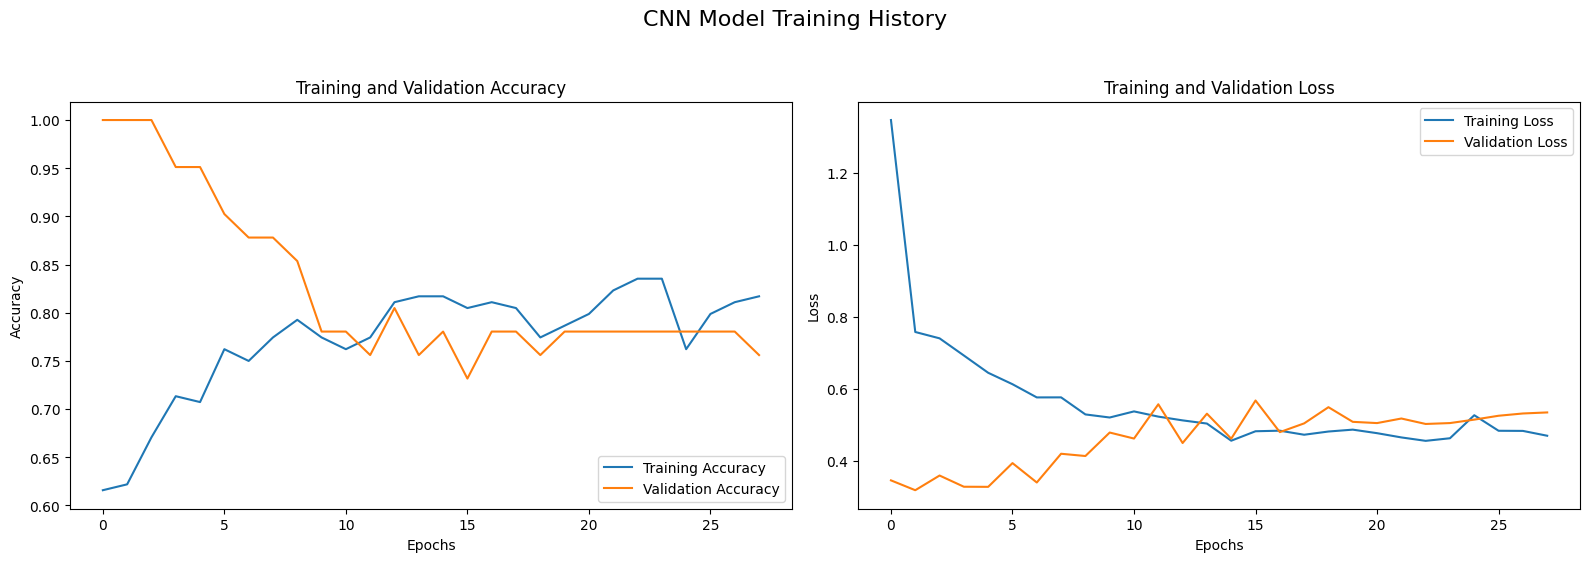

In [99]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))

    # Create a 2x2 grid of plots
    plt.figure(figsize=(16, 10))
    
    # Plot 1: Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Plot 2: Loss
    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.suptitle("CNN Model Training History", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_training_history(hist)

In [57]:
# Notes:
# 2 Layers => Accuracy of 90% on training data -> 80% on Validation data. Both increasing
#          => Loss consistently dropping but much spikier on validation data
# Potential improvement -> Early Stopping?
# 3 Layers => Accuracy above 90% for the training data but validation is much more volatile and hovers at about 70-80%
#             without any consistent improvement after the 20th epoch.
#          => Loss goes down consistently in the training set but is very erratic in the validation set with an upwards trend towards the end (overfitting?)
#          => Recall seems to confirm overfitting, validation set is very unstable when trying to find all positive cases. 
# Attempting adding early stopping next.
# Early stopping decided the best model was after 10 epochs.. adjusting learning rate and number of layers.. 
# 5 Layers and 0.0001 lr => Metrics seem more stable, Accuracy and precision are a solid 75%, Recall is looking much better at around 90%
# Doubling dropout rate 0.2 -> 0.4 
# Found copypasta in CNN model code, graphs are looking erratic after fix. Reducing layers.
# Training accuracy hitting 1 VERY early with a loss near zero, seems like overfitting. Adding regulatization and keras ReduceLROnPlateau function
# Graphs are looking better, much more stable